In [1]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

In [2]:
E_min = 6.7
E_max = 7.3
n_bins = 1000  # similar to Resolve's number of channels in the range

energy = np.linspace(E_min, E_max, n_bins)
dE = energy[1] - energy[0]

In [3]:
def simulate_spectrum():

    # Continuum parameters
    Gamma = np.random.uniform(0.8, 2.0)
    A = np.random.uniform(1, 100)

    continuum = A * (energy / 6.2)**(-Gamma)

    # Decide if line exists
    line_present = np.random.rand() > 0.5

    if line_present:

        # centroid
        E0 = np.random.uniform(6.903, 7.043)

        # line width
        sigma = np.random.uniform(0.007, 0.07)

        # continuum level at line
        C0 = A * (E0 / 6.2)**(-Gamma)

        # Equivalent width (keV)
        EW = np.random.uniform(0.005, 0.15)

        # total line flux
        F = EW * C0

    else:

        F, E0, sigma = 0.0, 6.973, 1.0


    gaussian = (F / (np.sqrt(2*np.pi)*sigma)) * \
               np.exp(-(energy - E0)**2 / (2*sigma**2))

    model_counts = continuum + gaussian

    noisy_counts = np.random.poisson(np.maximum(model_counts, 0))
    noisy_counts = noisy_counts / np.max(noisy_counts)   ## normalize spectrum maximum 1.

    E0_scaled = (E0 - 6.973) / 0.1
    sigma_scaled = sigma / 0.05

    return noisy_counts.astype(np.float32), \
           np.array([line_present, E0_scaled, sigma_scaled], dtype=np.float32)

In [4]:
class SpectraDataset(Dataset):
    def __init__(self, n_samples):
        self.X = []
        self.y = []

        for _ in range(n_samples):
            spec, label = simulate_spectrum()
            self.X.append(spec)
            self.y.append(label)

        self.X = torch.tensor(self.X).unsqueeze(1)  # shape: (N, 1, bins)
        self.y = torch.tensor(self.y)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [5]:
train_dataset = SpectraDataset(14000)
test_dataset  = SpectraDataset(6000)


train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64)

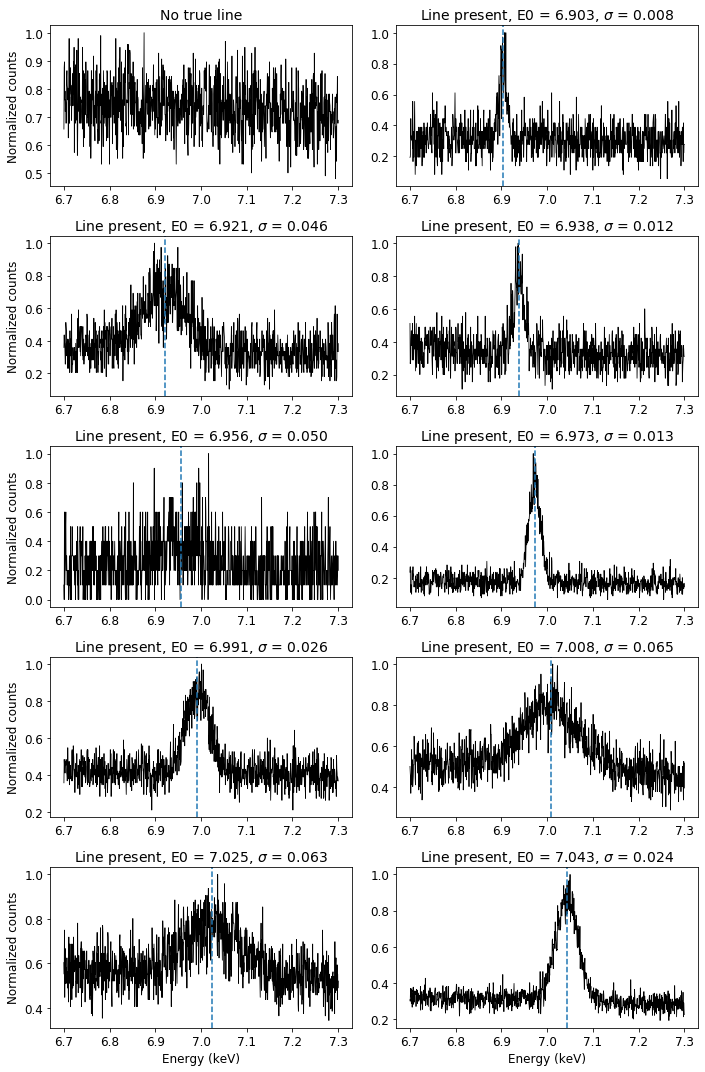

In [6]:
# ---------------------------------------
# Split dataset into line / no-line cases
# ---------------------------------------
line_indices = []
no_line_indices = []

for idx in range(len(test_dataset)):
    _, label = test_dataset[idx]
    line_present = int(label[0].item())

    if line_present == 1:
        line_indices.append(idx)
    else:
        no_line_indices.append(idx)
        

# ---------------------------------------
# Pick 1 spectrum with no line
# ---------------------------------------
idx_no_line = np.random.choice(no_line_indices)


# ---------------------------------------
# Collect line properties for all spectra with lines
# ---------------------------------------
line_info = []
for idx in line_indices:
    _, label = test_dataset[idx]

    E0_true = 6.973 + 0.1 * label[1].item()
    sigma_true = 0.05 * label[2].item()

    line_info.append((idx, E0_true, sigma_true))
    

# ---------------------------------------
# Sort to get a variety of line properties
# ---------------------------------------
line_info.sort(key=lambda x: (x[1], x[2]))


# Pick 9 spread-out spectra from the sorted list
positions = np.linspace(0, len(line_info) - 1, 9, dtype=int)
idx_with_lines = [line_info[p][0] for p in positions]


# Final set of 10 spectra
indices = [idx_no_line] + idx_with_lines


# ---------------------------------------
# Plot
# ---------------------------------------
fig, axes = plt.subplots(5, 2, figsize=(10, 15))
axes = axes.flatten()

for i, (ax, idx) in enumerate(zip(axes, indices)):
    spectrum, label = test_dataset[idx]
    spectrum_np = spectrum.squeeze().numpy()

    line_present = int(label[0].item())
    true_centroid = 6.973 + 0.1 * label[1].item()
    true_sigma = 0.05 * label[2].item()

    ax.plot(energy, spectrum_np, color='k',lw=0.8)
    ax.tick_params(axis='both', labelsize=12)

    if line_present:
        ax.axvline(true_centroid, linestyle='--')
        ax.set_title(rf'Line present, E0 = {true_centroid:.3f}, $\sigma$ = {true_sigma:.3f}',fontsize=14)
    else:
        ax.set_title('No true line',fontsize=14)

    if i // 2 == 4:
        ax.set_xlabel('Energy (keV)',fontsize=12)
    if i % 2 == 0:
        ax.set_ylabel('Normalized counts',fontsize=12)

plt.tight_layout()
plt.show()

In [7]:
class LineNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv1d(1, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool1d(kernel_size=2)

        self.conv2 = nn.Conv1d(16, 32, kernel_size=3, padding=1)

        self.dropout = nn.Dropout(0.2)

        self.fc1 = nn.Linear(32 * (n_bins // 2), 64)
        self.fc2 = nn.Linear(64, 3)  # class + centroid + sigma

    def forward(self, x):

        x = torch.relu(self.conv1(x))
        x = self.pool(x)

        x = torch.relu(self.conv2(x))
        #x = self.pool(x)    #if add this, change n_bins // 4

        x = x.view(x.size(0), -1)
        x = self.dropout(x)

        x = torch.relu(self.fc1(x))
        x = self.dropout(x)

        return self.fc2(x)

In [8]:
model = LineNet()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

bce = nn.BCEWithLogitsLoss()
mse = nn.MSELoss()

In [9]:
def compute_loss(outputs, targets):

    class_logits = outputs[:, 0]
    E0_pred       = outputs[:, 1]
    sigma_pred_raw = outputs[:, 2]

    line_true = targets[:, 0]
    E0_true   = targets[:, 1]
    sigma_true = targets[:, 2]



    # classification loss
    loss_class = bce(class_logits, line_true)

    # enforce positive width, and +1e-6 avoid division by zero
    sigma_pred = nn.functional.softplus(sigma_pred_raw) + 1e-6

    mask = line_true > 0.5

    if mask.sum() > 0:
        loss_E0 = mse(E0_pred[mask], E0_true[mask])
        loss_sigma = mse(sigma_pred[mask], sigma_true[mask])
    else:
        loss_E0 = torch.tensor(0.0, device=outputs.device)
        loss_sigma = torch.tensor(0.0, device=outputs.device)

    loss = loss_class + 0.1 * loss_E0 + 0.3 * loss_sigma
    return loss

In [10]:
for epoch in range(20):

    model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = compute_loss(outputs, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f'Epoch {epoch}: {total_loss:.3f}')

Epoch 0: 108.443
Epoch 1: 63.552
Epoch 2: 46.900
Epoch 3: 37.572
Epoch 4: 32.099
Epoch 5: 28.392
Epoch 6: 24.717
Epoch 7: 23.498
Epoch 8: 21.971
Epoch 9: 20.689
Epoch 10: 20.568
Epoch 11: 19.492
Epoch 12: 18.093
Epoch 13: 17.650
Epoch 14: 16.925
Epoch 15: 16.485
Epoch 16: 16.469
Epoch 17: 15.812
Epoch 18: 14.902
Epoch 19: 14.803


In [11]:
def mc_predict(model, x, n_samples=200):
    model.train()   # keep dropout on

    predictions = []
    for _ in range(n_samples):
        pred = model(x.unsqueeze(0))
        predictions.append(pred.detach().cpu())

    predictions = torch.stack(predictions)   # shape: [n_samples, 1, n_outputs]

    class_logits = predictions[:, 0, 0]
    E0_samples   = predictions[:, 0, 1]
    sigma_samples = nn.functional.softplus(predictions[:, 0, 2]) + 1e-6

    prob_samples = torch.sigmoid(class_logits)

    results = {
        'prob_mean': prob_samples.mean().item(),
        'prob_std': prob_samples.std().item(),
        'E0_mean': E0_samples.mean().item(),
        'E0_std': E0_samples.std().item(),
        'sigma_mean': sigma_samples.mean().item(),
        'sigma_std': sigma_samples.std().item(),
    }
    return results

In [12]:
model.eval()
correct = 0
total = 0

for X_batch, y_batch in test_loader:
    outputs = model(X_batch)
    preds = torch.sigmoid(outputs[:,0]) > 0.5
    correct += (preds == y_batch[:,0]).sum().item()
    total += len(y_batch)

print('Accuracy:', correct/total)

Accuracy: 0.984


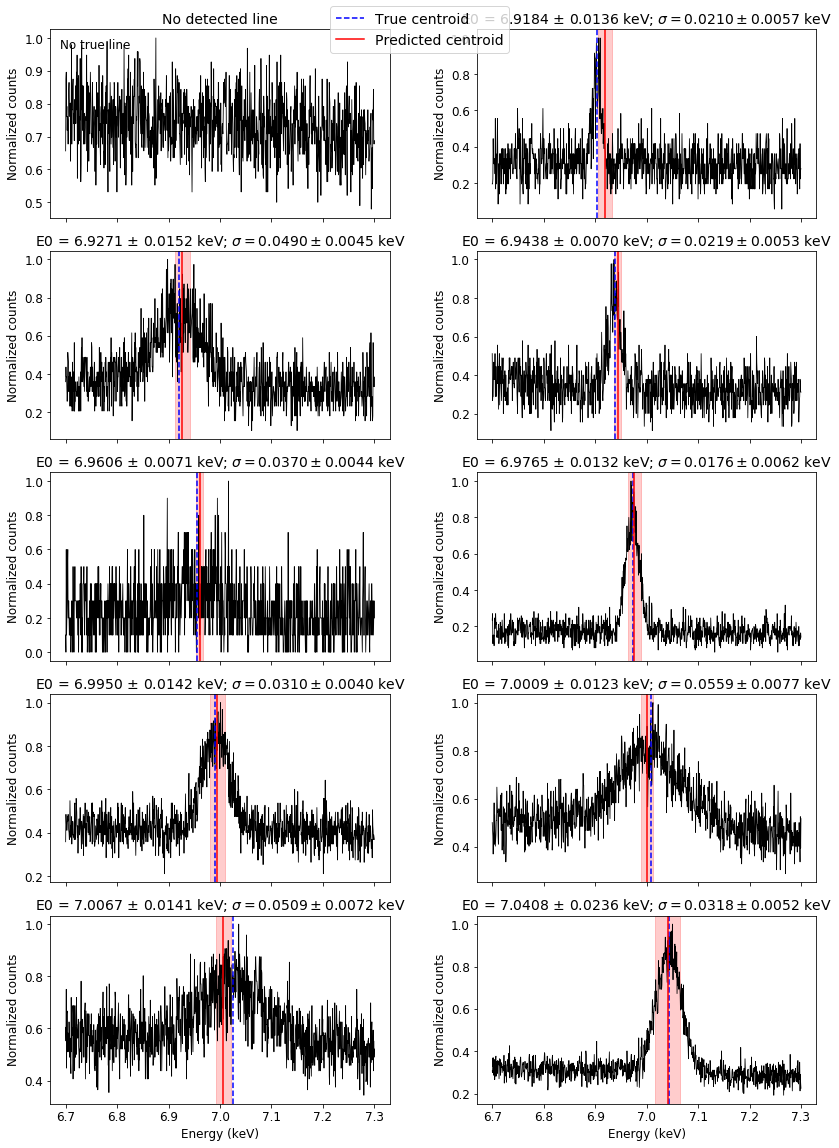

In [13]:
energy_grid = np.linspace(6.7, 7.3, n_bins)

fig, axes = plt.subplots(5, 2, figsize=(12, 16), sharex=True)
axes = axes.flatten()

for ax, i in zip(axes, indices):
    x, y = test_dataset[i]

    spec = x.squeeze().cpu().numpy()

    # --- Truth ---
    line_true = y[0].item()
    E0_true = 6.973 + 0.1 * y[1].item()
    sigma_true = 0.05 * y[2].item()

    # --- MC prediction ---
    pred = mc_predict(model, x, n_samples=200)

    prob_mean = pred['prob_mean']
    E0_mean   = 6.973 + 0.1 * pred['E0_mean']
    E0_std    = 0.1 * pred['E0_std']

    sigma_mean = 0.05 * pred['sigma_mean']
    sigma_std  = 0.05 * pred['sigma_std']

    # --- Plot spectrum ---
    ax.plot(energy_grid, spec, lw=0.8, color='k')

    # --- True centroid ---
    if line_true > 0.5:
        ax.axvline(E0_true, linestyle="--", linewidth=1.5, label='True centroid',color='b')
    else:
        ax.text(0.03, 0.90, 'No true line', transform=ax.transAxes, fontsize=12)

    # --- Predicted ---
    if prob_mean > 0.5:
        ax.axvline(E0_mean, linewidth=1.5, label='Predicted centroid',color='r')
        ax.axvspan(E0_mean - E0_std, E0_mean + E0_std,
                   alpha=0.2,color='r')

        title = (
            rf'E0 = {E0_mean:.4f} $\pm$ {E0_std:.4f} keV; '
            rf'$\sigma = {sigma_mean:.4f} \pm {sigma_std:.4f}$ keV'
        )
    else:
        title = 'No detected line'

    ax.set_title(title, fontsize=14)
    ax.set_ylabel('Normalized counts', fontsize=12)
    ax.tick_params(axis='both', labelsize=12)

axes[-2].set_xlabel('Energy (keV)',fontsize=12)
axes[-1].set_xlabel('Energy (keV)',fontsize=12)

# better legend
handles, labels = [], []
for ax in axes:
    h, l = ax.get_legend_handles_labels()
    handles += h
    labels += l

unique = dict(zip(labels, handles))
fig.legend(unique.values(), unique.keys(), loc='upper center',fontsize=14)

plt.tight_layout()
plt.show()

In [14]:
model.eval()

y_true = []
y_pred = []

for X_batch, y_batch in test_loader:

    with torch.no_grad():
        outputs = model(X_batch)

    probs = torch.sigmoid(outputs[:,0])
    preds = (probs > 0.5).cpu().numpy()

    y_true.extend(y_batch[:,0].cpu().numpy())
    y_pred.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [15]:
cm = confusion_matrix(y_true, y_pred)

print(cm)

[[2981    4]
 [  92 2923]]


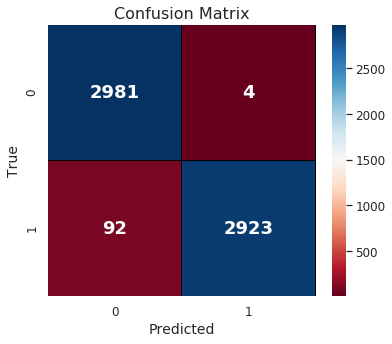

In [16]:
plt.figure(figsize=(6,5))

sns.set(font_scale=1.2)  # overall scaling (good baseline)

ax = sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='RdBu',
    center=cm.mean(),
    linewidths=0.5,
    linecolor='black',
    annot_kws={"size": 18, "weight": "bold"}  # numbers inside boxes
)

# axis labels + title
ax.set_xlabel('Predicted', fontsize=14)
ax.set_ylabel('True', fontsize=14)
ax.set_title('Confusion Matrix', fontsize=16)

# tick labels (0,1)
ax.tick_params(axis='both', labelsize=12)

# colorbar ticks
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=12)

plt.show()

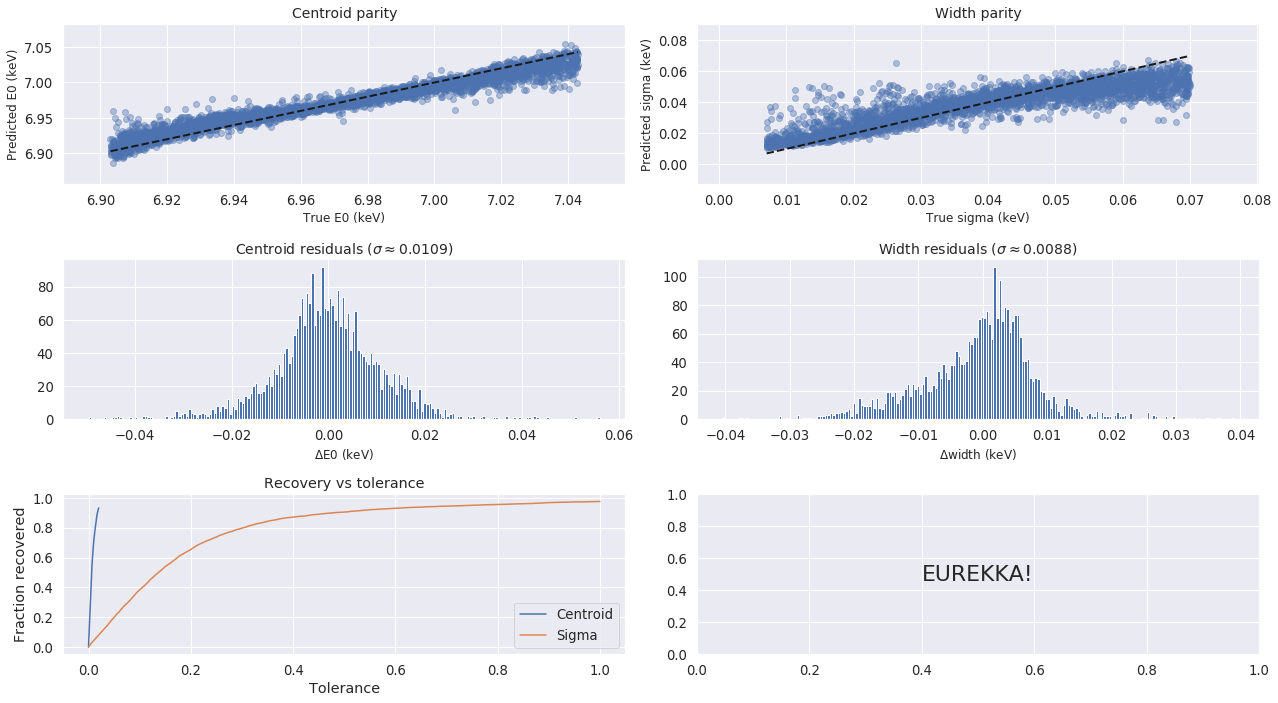

Centroid within 10 eV (Resolve's energy resolution): 0.6975124378109453
Sigma within 20%: 0.6547263681592039
Both correct: 0.4802653399668325


In [17]:
model.eval()

E0_true_list, E0_pred_list = [], []
sigma_true_list, sigma_pred_list = [], []

# -------------------------------
# Collect predictions
# -------------------------------
for X_batch, y_batch in test_loader:

    with torch.no_grad():
        outputs = model(X_batch)

    probs = torch.sigmoid(outputs[:, 0])
    line_true = y_batch[:, 0] > 0.5

    mask = line_true  # only true lines

    if mask.sum() == 0:
        continue

    # predictions
    E0_pred = 6.973 + 0.1 * outputs[:, 1]
    sigma_pred = 0.05 * (nn.functional.softplus(outputs[:, 2]) + 1e-6)

    # truth
    E0_true = 6.973 + 0.1 * y_batch[:, 1]
    sigma_true = 0.05 * y_batch[:, 2]

    # store
    E0_true_list.extend(E0_true[mask].cpu().numpy())
    E0_pred_list.extend(E0_pred[mask].cpu().numpy())

    sigma_true_list.extend(sigma_true[mask].cpu().numpy())
    sigma_pred_list.extend(sigma_pred[mask].cpu().numpy())

# convert to arrays
E0_true = np.array(E0_true_list)
E0_pred = np.array(E0_pred_list)

sigma_true = np.array(sigma_true_list)
sigma_pred = np.array(sigma_pred_list)

# -------------------------------
# Residuals
# -------------------------------
E0_resid = E0_pred - E0_true
sigma_resid = sigma_pred - sigma_true

# -------------------------------
# Fraction recovered curves
# -------------------------------
tol_E0 = np.linspace(0, 0.02, 200)
frac_E0 = [(np.abs(E0_resid) < t).mean() for t in tol_E0]

sigma_frac_err = np.abs(sigma_resid) / sigma_true
tol_sigma = np.linspace(0, 1.0, 200)
frac_sigma = [(sigma_frac_err < t).mean() for t in tol_sigma]

# -------------------------------
# Plot all together
# -------------------------------
fig, axs = plt.subplots(3, 2, figsize=(18, 10))

# --- Centroid parity ---
axs[0,0].scatter(E0_true, E0_pred, alpha=0.4,color='b')
xmin, xmax = E0_true.min(), E0_true.max()
axs[0,0].plot([xmin, xmax], [xmin, xmax], '--',lw=2., color='k')
axs[0,0].set_xlabel('True E0 (keV)',fontsize=12)
axs[0,0].set_ylabel('Predicted E0 (keV)',fontsize=12)
axs[0,0].set_title('Centroid parity',fontsize=14)

# --- Sigma parity ---
axs[0,1].scatter(sigma_true, sigma_pred, alpha=0.4,color='b')
xmin, xmax = sigma_true.min(), sigma_true.max()
axs[0,1].plot([xmin, xmax], [xmin, xmax], '--',lw=2., color='k')
axs[0,1].set_xlabel('True sigma (keV)',fontsize=12)
axs[0,1].set_ylabel('Predicted sigma (keV)',fontsize=12)
axs[0,1].set_title('Width parity',fontsize=14)

# --- Centroid residuals ---
axs[1,0].hist(E0_resid, bins=200)
axs[1,0].set_xlabel(r'$\Delta$E0 (keV)',fontsize=12)
axs[1,0].set_title(rf'Centroid residuals ($\sigma \approx {E0_resid.std():.4f}$)',fontsize=14)


# --- Sigma residuals ---
axs[1,1].hist(sigma_resid, bins=200)
axs[1,1].set_xlabel(r'$\Delta$width (keV)',fontsize=12)
axs[1,1].set_title(rf'Width residuals ($\sigma \approx {sigma_resid.std():.4f}$)',fontsize=14)


# --- Fraction recovered ---
axs[2,0].plot(tol_E0, frac_E0, label='Centroid')
axs[2,0].plot(tol_sigma, frac_sigma, label='Sigma')
axs[2,0].set_xlabel('Tolerance')
axs[2,0].set_ylabel('Fraction recovered')
axs[2,0].set_title('Recovery vs tolerance')
axs[2,0].legend()


# --- Eureka ---
axs[2,1].text(0.5, 0.5, 'EUREKKA!', fontsize=22, ha='center', va='center', transform=axs[2,1].transAxes)


plt.tight_layout()
plt.show()

# -------------------------------
# Print summary metrics
# -------------------------------
centroid_ok = np.abs(E0_resid) < 0.01
sigma_ok = np.abs(sigma_resid) / sigma_true < 0.2

print('Centroid within 10 eV (Resolve\'s energy resolution):', centroid_ok.mean())
print('Sigma within 20%:', sigma_ok.mean())
print('Both correct:', (centroid_ok & sigma_ok).mean())

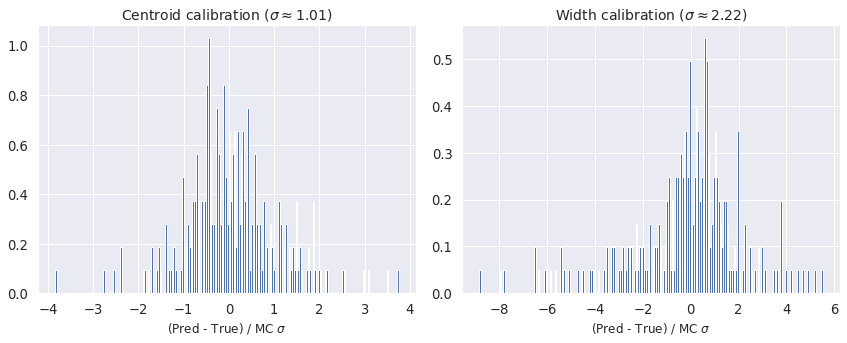

In [18]:
model.eval()

E0_errors = []
E0_unc = []

sigma_errors = []
sigma_unc = []

# -------------------------------
# Loop over test set
# -------------------------------
for i in range(600):  # subset for speed 20% of test dataset

    x, y = test_dataset[i]

    if y[0].item() < 0.5:
        continue  # only real lines

    # --- MC prediction ---
    pred = mc_predict(model, x, n_samples=100)

    # --- convert to physical ---
    E0_pred = 6.973 + 0.1 * pred['E0_mean']
    E0_std  = 0.1 * pred['E0_std']

    sigma_pred = 0.05 * pred['sigma_mean']
    sigma_std  = 0.05 * pred['sigma_std']

    E0_true = 6.973 + 0.1 * y[1].item()
    sigma_true = 0.05 * y[2].item()

    # store normalized residuals
    if E0_std > 0:
        E0_errors.append((E0_pred - E0_true) / E0_std)
        E0_unc.append(E0_std)

    if sigma_std > 0:
        sigma_errors.append((sigma_pred - sigma_true) / sigma_std)
        sigma_unc.append(sigma_std)

E0_errors = np.array(E0_errors)
sigma_errors = np.array(sigma_errors)

# -------------------------------
# Plot
# -------------------------------
fig, axs = plt.subplots(1, 2, figsize=(12,5))

# --- Centroid calibration ---
axs[0].hist(E0_errors, bins=200, density=True,color='b')
axs[0].set_title(rf'Centroid calibration ($\sigma \approx {E0_errors.std():.2f}$)',fontsize=14)
axs[0].set_xlabel(r'(Pred - True) / MC $\sigma$',fontsize=12)

# --- Sigma calibration ---
axs[1].hist(sigma_errors, bins=200, density=True,color='b')
axs[1].set_title(rf'Width calibration ($\sigma \approx {sigma_errors.std():.2f}$)',fontsize=14)
axs[1].set_xlabel(r'(Pred - True) / MC $\sigma$',fontsize=12)

plt.tight_layout()
plt.show()

In [20]:
from sklearn.metrics import f1_score

f1 = f1_score(y_true, y_pred)

In [21]:
f1

0.9838438236284079

In [29]:
class_logits = outputs[:, 0]
E0_pred      = outputs[:, 1]
sigma_pred   = nn.functional.softplus(outputs[:, 2]) + 1e-6   

line_true  = y_batch[:, 0]
E0_true    = y_batch[:, 1]
sigma_true = y_batch[:, 2]



mask = line_true > 0.5


if mask.sum() > 0:

    mae_E0 = torch.mean(torch.abs(E0_pred[mask] - E0_true[mask]))

    rel_err_sigma = torch.mean(
        torch.abs((sigma_pred[mask] - sigma_true[mask]) / sigma_true[mask])
    )

    print('MAE E0:', 0.1*mae_E0.item(),' keV')
    print(r'Relative error $\sigma$:', 100*rel_err_sigma.item(),'%')

MAE E0: 0.007009977102279664  keV
Relative error $\sigma$: 24.000154435634613 %
